In [19]:
import pandas as pd
import numpy as np

# Load files
try:
    g60_file = r'C:\usrspace\mywork\data_paper2\visibile_data\G60\path\G60_0_to_86400.csv'
    gw_file = r'C:\usrspace\mywork\data_paper2\visibile_data\GW\path\GW_0_to_86400.csv'

    # Read files, skip lines starting with '#'
    g60_df = pd.read_csv(g60_file)
    gw_df = pd.read_csv(gw_file)

except Exception as e:
    print(f"Error reading files: {e}")
    exit(1)

# Sidereal day
sidereal_day = 86164


# Filter for 1 sidereal day
g60_data = g60_df[g60_df['time'] <= sidereal_day].copy()
gw_data = gw_df[gw_df['time'] <= sidereal_day].copy()


In [20]:
# 设定你需要的列名
target_col = 'avg_shortest_path'

# 1. 过滤并转换为 Series (Time -> Value)
# set_index('time') 将时间变为下标，然后只取 target_col 这一列
g60_series = g60_df[g60_df['time'] <= sidereal_day].set_index('time')[target_col].copy()
gw_series = gw_df[gw_df['time'] <= sidereal_day].set_index('time')[target_col].copy()

# 现在：
# g60_series[0] 就是 t=0 时的跳数
# g60_series[100] 就是 t=100 时的跳数

In [11]:
import matplotlib.pyplot as plt

def plot_curves(series_dict, title="Constellation Network Performance", show_grid=True):
    """
    绘制一条或多条曲线。

    参数:
        series_dict: 字典格式 { '图例名称': pandas_series, ... }
                     例如: {'G60': g60_series, 'GW (Shifted)': gw_new_curve}
        title:       图表标题
    """
    plt.figure(figsize=(12, 5)) # 设置画布大小 (宽, 高)

    # 遍历字典，画出每一条线
    for label_name, series_data in series_dict.items():
        plt.plot(series_data.index, series_data.values, label=label_name, linewidth=1.5)

    # 设置图表细节
    plt.xlabel("Time (seconds)")       # X轴标签
    plt.ylabel("Avg Shortest Path (Hops)") # Y轴标签
    plt.title(title)                   # 标题
    plt.xlim(0, 86164)                 # 限制X轴范围为一个恒星日

    if show_grid:
        plt.grid(True, linestyle='--', alpha=0.6) #加上网格，看着更清晰

    plt.legend() # 显示图例
    plt.show()

# ==========================================
# 使用示例 1：只画 G60
# ==========================================
# plot_curves({'G60 Only': g60_series})

# ==========================================
# 使用示例 2：画 G60 和 移动后的 GW 对比
# ==========================================
# 假设你已经用上面的函数得到了 gw_new_curve


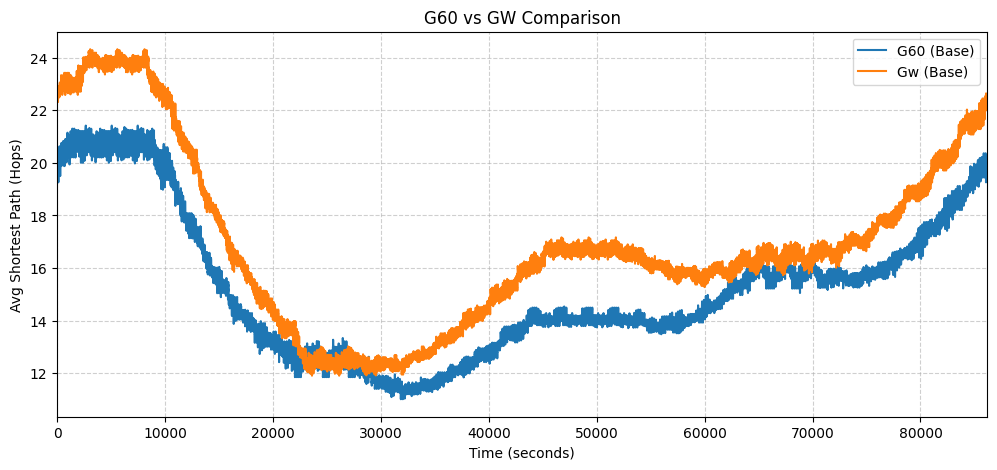

In [21]:
plot_curves({
    'G60 (Base)': g60_series,
      'Gw (Base)': gw_series,

}, title="G60 vs GW Comparison")

In [23]:
def get_shifted_series(target_series, shift_seconds):
    """
    对 Series 数据进行周期性时间平移 (Circular Shift)，确保不修改原始输入数据。

    参数:
        target_series:  原始数据的 Series (Index=Time, Value=Metric)
        shift_seconds:  需要移动的时间量 (s)。

    返回:
        shifted_series: 平移后的新 Series (Index不变，Value循环移动)
    """
    # 1. 【关键】创建副本或提取 Values 生成新数组，确保不影响原数据
    # target_series.values 返回的是 numpy array，np.roll 会生成一个新的 array，
    # 所以原 series 的 values 不会被修改。
    original_values = target_series.values
    original_index = target_series.index

    # 2. 计算采样间隔 dt
    if len(original_index) > 1:
        # 假设均匀采样，取前两个点的时间差
        dt = original_index[1] - original_index[0]
    else:
        dt = 1.0

    # 3. 计算移动步数 k
    # k = shift / dt
    k_steps = int(round(shift_seconds / dt))

    # 4. 执行循环移位
    # np.roll 返回的是一个新的数组对象，不会修改 original_values
    shifted_values = np.roll(original_values, k_steps)

    # 5. 组装成全新的 Series
    # name属性也复制一下，保持一致性
    new_series = pd.Series(data=shifted_values, index=original_index, name=target_series.name)

    return new_series

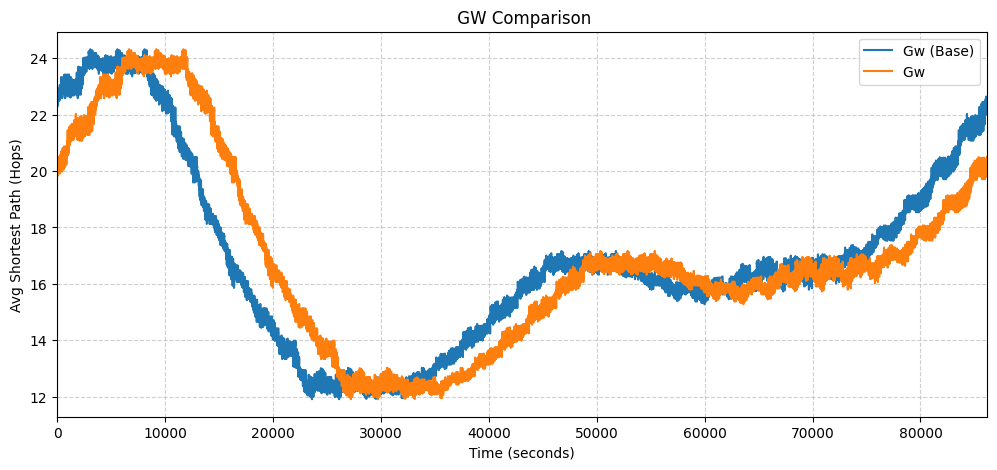

In [26]:
# 1. 假设你要把 GW 曲线向后移动 3600 秒,jiushi you jiushi -
gw_shifted = get_shifted_series(gw_series, 3600)

# 2. 直接绘图对比

plot_curves({
    'Gw (Base)': gw_series,
      'Gw  ': gw_shifted,

}, title=" GW Comparison")


In [27]:


def calculate_hn_envelope(series_g60, series_gw):
    """
    计算两个星座的逐时刻最优包络序列 h[n]。
    对应公式: h[n] = min(g[n], f[n])

    参数:
        series_g60: G60 的数据序列 (pandas.Series)
        series_gw:  GW 的数据序列 (pandas.Series，可以是原始的也可以是移动后的)

    返回:
        h_series:   联合最优包络序列 (pandas.Series)
    """
    # 1. 使用 numpy 的 minimum 函数进行逐元素比较
    # 这会对比两个序列在每一秒的值，取较小值
    h_values = np.minimum(series_g60.values, series_gw.values)

    # 2. 组装成 Series，保持时间索引不变
    h_series = pd.Series(data=h_values, index=series_g60.index, name='Envelope_hn')

    return h_series

In [28]:
# 1. 准备数据：先移动 GW
gw_shifted = get_shifted_series(gw_series, 3600)

# 2. 计算 h[n] (调用上面的函数)
hn_series = calculate_hn_envelope(g60_series, gw_shifted)

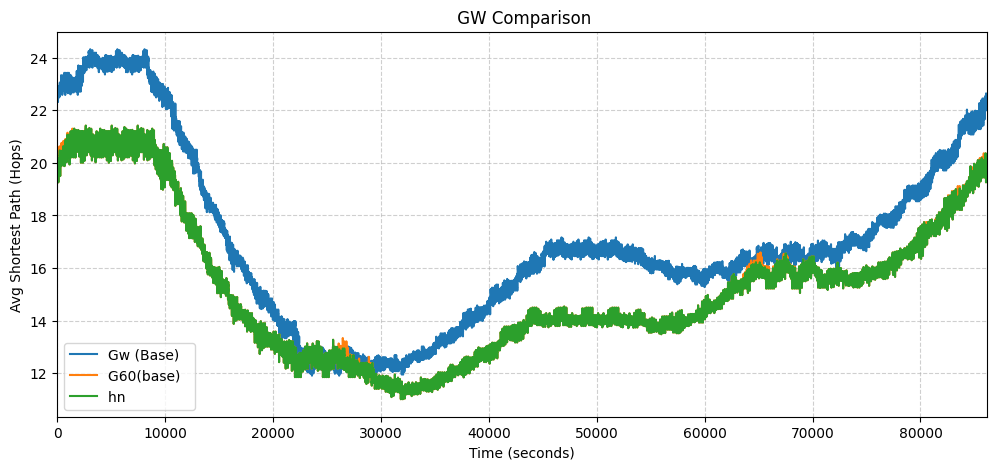

In [30]:
# 1. 准备数据：先移动 GW
gw_shifted = get_shifted_series(gw_series, 3600)

# 2. 计算 h[n] (调用上面的函数)
hn_series = calculate_hn_envelope(g60_series, gw_shifted)
plot_curves({
    'Gw (Base)': gw_series,
      'G60(base)  ': g60_series,
    'hn  ': hn_series,

}, title=" GW Comparison")


In [31]:
import numpy as np
import pandas as pd
import time

def calculate_all_pi_k(g60_series, gw_series):
    """
    遍历每一个平移量 k，计算对应的平均跳数 pi[k]。

    参数:
        g60_series: 固定星座序列
        gw_series:  待移动星座序列

    返回:
        results_df: 包含 'k_step', 'shift_time', 'raan_offset', 'pi_score' 的 DataFrame
                    方便后续直接画图分析变化情况。
    """
    # 1. 提取 Numpy 数组 (为了极速计算)
    g_arr = g60_series.values
    f_arr = gw_series.values
    time_index = g60_series.index.values

    N = len(g_arr)

    # 计算采样时间间隔 dt (用于把 k 换算成秒)
    if N > 1:
        dt = time_index[1] - time_index[0]
    else:
        dt = 1.0

    print(f"开始遍历全周期，共有 {N} 个采样点...")
    start_time = time.time()

    # 用于存放结果的列表
    pi_scores = []

    # 2. 循环遍历所有可能的 k
    for k in range(N):
        # A. 移动 GW (f_k)
        # np.roll: 数组元素向右循环移动 k 位
        f_k = np.roll(f_arr, k)

        # B. 计算逐时刻最优包络 (h_k)
        h_k = np.minimum(g_arr, f_k)

        # C. 计算该状态下的平均值 (pi[k])
        pi_val = np.mean(h_k)

        pi_scores.append(pi_val)

        # (可选) 每隔 10000 次打印一下进度
        if k % 10000 == 0 and k > 0:
            print(f"已处理 k={k}/{N} ...")

    elapsed = time.time() - start_time
    print(f"遍历完成，耗时: {elapsed:.2f} 秒")

    # 3. 整理结果返回 DataFrame
    # 构造 k 的序列
    k_indices = np.arange(N)

    # 构造对应的时间偏移 (Shift Time)
    shift_times = k_indices * dt

    # 构造对应的 RAAN 角度 (假设周期对应 360度)
    # RAAN = (k / N) * 360
    raan_offsets = (k_indices / N) * 360.0

    results_df = pd.DataFrame({
        'k_step': k_indices,
        'shift_seconds': shift_times,
        'raan_offset_deg': raan_offsets,
        'pi_score': pi_scores  # 这就是你要的平均值序列
    })

    return results_df

开始遍历全周期，共有 86165 个采样点...
已处理 k=10000/86165 ...
已处理 k=20000/86165 ...
已处理 k=30000/86165 ...
已处理 k=40000/86165 ...
已处理 k=50000/86165 ...
已处理 k=60000/86165 ...
已处理 k=70000/86165 ...
已处理 k=80000/86165 ...
遍历完成，耗时: 12.18 秒
最优 RAAN 偏移: 242.08 度
此时最低平均跳数: 13.6664


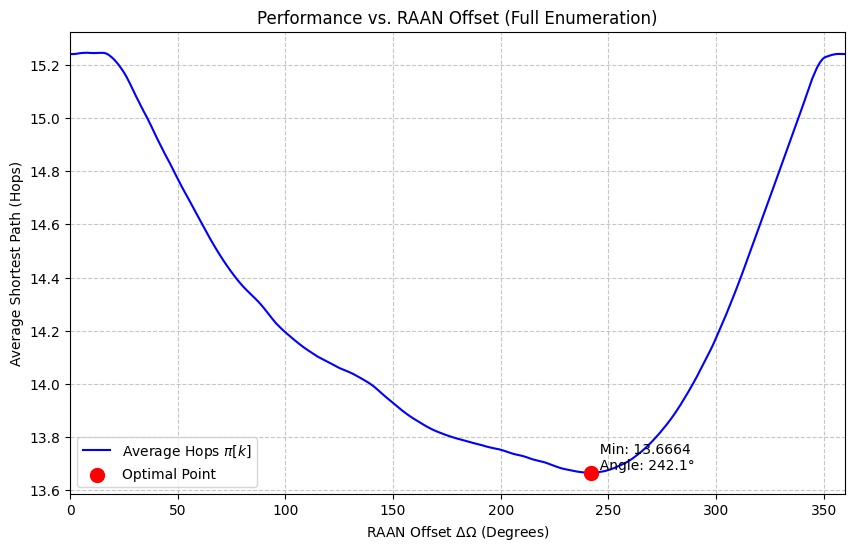

In [32]:
# 1. 执行全遍历计算
# 这一步可能会花几秒钟
df_results = calculate_all_pi_k(g60_series, gw_series)

# 2. 找到最小值及其位置 (为了在图上标记)
min_row = df_results.loc[df_results['pi_score'].idxmin()]
print(f"最优 RAAN 偏移: {min_row['raan_offset_deg']:.2f} 度")
print(f"此时最低平均跳数: {min_row['pi_score']:.4f}")

# 3. 绘制变化曲线
plt.figure(figsize=(10, 6))

# X轴: RAAN 偏移角度 (0 到 360)
# Y轴: 平均跳数 pi[k]
plt.plot(df_results['raan_offset_deg'], df_results['pi_score'],
         label='Average Hops $\pi[k]$', color='blue')

# 标记最优点
plt.scatter(min_row['raan_offset_deg'], min_row['pi_score'],
            color='red', s=100, label='Optimal Point', zorder=5)

# 添加标注文本
plt.text(min_row['raan_offset_deg'], min_row['pi_score'],
         f"  Min: {min_row['pi_score']:.4f}\n  Angle: {min_row['raan_offset_deg']:.1f}°",
         verticalalignment='bottom')

plt.title('Performance vs. RAAN Offset (Full Enumeration)')
plt.xlabel('RAAN Offset $\Delta\Omega$ (Degrees)')
plt.ylabel('Average Shortest Path (Hops)')
plt.xlim(0, 360)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [33]:
df_results

,k_step,shift_seconds,raan_offset_deg,pi_score
0,0,0,0.000000,15.239826
1,1,1,0.004178,15.239830
2,2,2,0.008356,15.239834
3,3,3,0.012534,15.239844
4,4,4,0.016712,15.239849
...,...,...,...,...
86160,86160,86160,359.979110,15.239814
86161,86161,86161,359.983288,15.239825
86162,86162,86162,359.987466,15.239832
86163,86163,86163,359.991644,15.239830


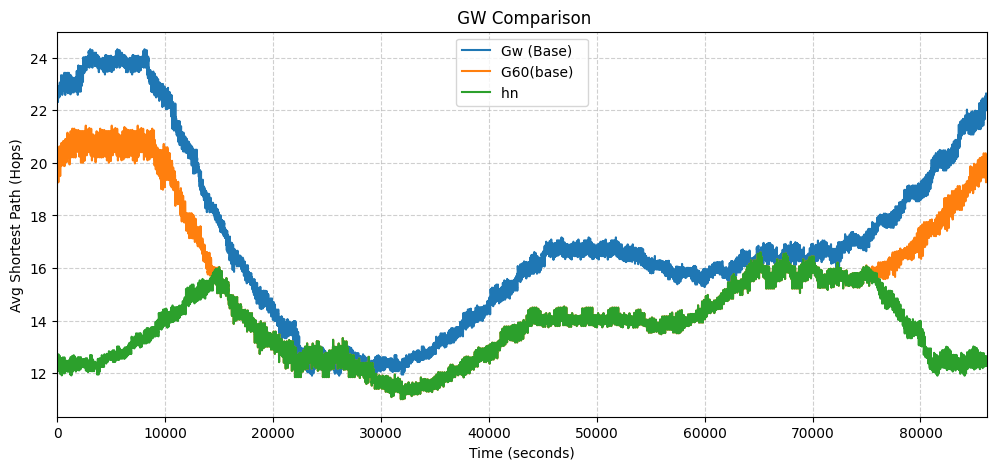

In [34]:
# 1. 准备数据：先移动 GW
gw_shifted = get_shifted_series(gw_series, 57945)

# 2. 计算 h[n] (调用上面的函数)
hn_series = calculate_hn_envelope(g60_series, gw_shifted)
plot_curves({
    'Gw (Base)': gw_series,
      'G60(base)  ': g60_series,
    'hn  ': hn_series,

}, title=" GW Comparison")
